In [1]:
import wandb

# Login to W&B if not already
# wandb.login(key='8e2d9cdd5b5b4d8f1b229cb2a6fc8fa5e1776e1a')

api = wandb.Api()
runs = api.runs("eaev-uc-berkeley/euclid-jwst-hyperparameter-sweep-v3")

# Find best run
best_run = min(runs, key=lambda r: r.summary.get('final_sweep_loss', float('inf')))

print(f"Best run: {best_run.id}")
print(f"Loss: {best_run.summary['final_sweep_loss']:.6f}")
print(f"Config: {best_run.config}")
print(f"Name: {best_run.name}")

# # Download its artifacts
# for artifact in best_run.logged_artifacts():
#     if 'model' in artifact.type.lower():
#         artifact.download('./best_model')
#         break

/global/homes/e/eramey16/.conda/envs/myprospector/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/global/homes/e/eramey16/.conda/envs/myprospector/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment

Best run: tbra2akh
Loss: 0.686611
Config: {'device': 'cuda', 'features': 64, 'num_rrdb': 8, 'val_size': 10645, 'jwst_path': '../data/jwst_cosmos_205px_F115W.npy', 'lr_stage1': 5.662124820190853e-05, 'lr_stage2': 9.223193223543192e-05, 'val_split': 0.2, 'batch_size': 16, 'train_size': 42584, 'euclid_path': '../data/euclid_NIR_cosmos_41px_Y.npy', 'weight_decay': 1.2151589337635651e-05, 'normalization': 'z_score', 'l1_weight_stage1': 0.8, 'optimizer_stage1': 'Adam', 'optimizer_stage2': 'Adam', 'mse_weight_stage2': 0.1, 'gradient_clip_norm': 1, 'ssim_weight_stage2': 0.5}
Name: vibrant-sweep-29


# Dataloader that works with the hdf5 and can load both lr/hr for training and only lr for inference

In [2]:
train_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="train"
)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # (16, 1, 25, 25)
print("HR Batch Shape:", hr_batch.shape)  # (16, 1, 125, 125)

test_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="test"
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # (16, 1, 25, 25)
print("HR Batch Shape:", hr_batch.shape)  # (16, 1, 125, 125)


Training Mode:
LR Batch Shape: torch.Size([16, 1, 25, 25])
HR Batch Shape: torch.Size([16, 1, 125, 125])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 25, 25])
HR Batch Shape: torch.Size([16, 1, 125, 125])


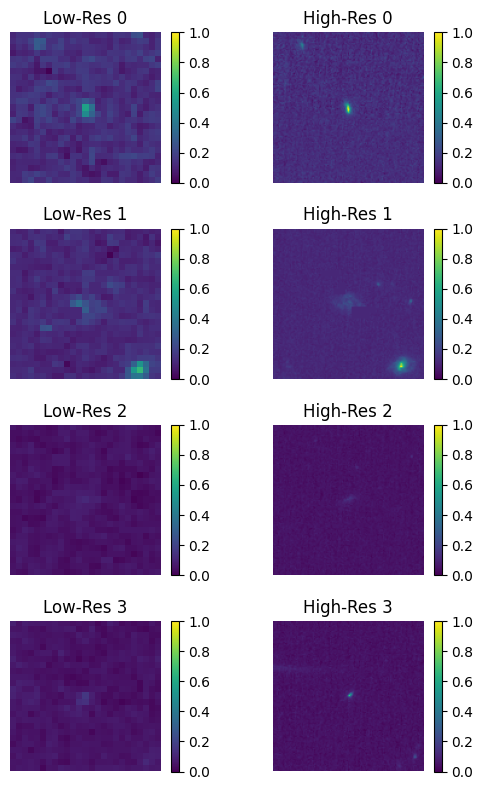

In [3]:
lr_hdf5_path = "../data/Nisp_train_cosmos.hdf5"
hr_hdf5_path = "../data/Nircam_train_cosmos.hdf5"

# === Load Training Dataset ===
train_dataset = SuperResolutionDataset(lr_hdf5_path, hr_hdf5_path, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# === Fetch a batch from the training dataset ===
lr_batch, hr_batch = next(iter(train_loader))

# === Convert tensors to NumPy ===
lr_batch_np = lr_batch.squeeze(1).cpu().numpy()  
hr_batch_np = hr_batch.squeeze(1).cpu().numpy()  

# === Shared color scale ===
vmin = min(lr_batch_np.min(), hr_batch_np.min())
vmax = max(lr_batch_np.max(), hr_batch_np.max())

# === Plot first 4 samples ===
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
# plt.savefig("superres_examples.png", dpi=300)  # Uncomment to save
plt.show()


# model

In [9]:
import os
import json
import wandb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from dataset import SuperResolutionDataset
import numpy as np
import math
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Set these at the beginning of your script
torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
torch.backends.cuda.matmul.allow_tf32 = True  # Allow TF32 for faster computation
torch.backends.cudnn.allow_tf32 = True

def compute_psnr_ssim(pred, target):
    pred_np = pred.squeeze().numpy()
    target_np = target.squeeze().numpy()
    psnr_val = peak_signal_noise_ratio(target_np, pred_np, data_range=1.0)
    ssim_val = structural_similarity(target_np, pred_np, data_range=1.0)
    return psnr_val, ssim_val

# Use channels_last memory format for better performance
def convert_to_channels_last(model):
    return model.to(memory_format=torch.channels_last)

def get_data_splits(dataset, val_split=0.2, test_split=0.1, seed=42, split_save_path="splits.json"):
    n_total = len(dataset)
    n_val = int(val_split * n_total)
    n_test = int(test_split * n_total)
    n_train = n_total - n_val - n_test

    if os.path.exists(split_save_path):
        with open(split_save_path, "r") as f:
            indices = json.load(f)
        print(f"Loaded split indices from {split_save_path}")
    else:
        torch.manual_seed(seed)
        all_indices = torch.randperm(n_total).tolist()
        indices = {
            "train": all_indices[:n_train],
            "val":   all_indices[n_train:n_train + n_val],
            "test":  all_indices[n_train + n_val:]
        }
        with open(split_save_path, "w") as f:
            json.dump(indices, f)
        print(f"Saved split indices to {split_save_path}")

    return {
        "train": Subset(dataset, indices["train"]),
        "val":   Subset(dataset, indices["val"]),
        "test":  Subset(dataset, indices["test"])
    }

class ResidualDenseBlock(nn.Module):
    """Enhanced Residual Dense Block with local feature fusion"""
    def __init__(self, channels, growth_rate=32):
        super(ResidualDenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, growth_rate, 3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_rate, growth_rate, 3, padding=1)
        self.conv3 = nn.Conv2d(channels + 2 * growth_rate, growth_rate, 3, padding=1)
        self.conv4 = nn.Conv2d(channels + 3 * growth_rate, growth_rate, 3, padding=1)
        self.conv5 = nn.Conv2d(channels + 4 * growth_rate, channels, 3, padding=1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        
    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x + x5  # Residual connection

class DetailEnhancementModule(nn.Module):
    """Advanced detail enhancement module"""
    def __init__(self, channels):
        super(DetailEnhancementModule, self).__init__()
        self.edge_conv = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, kernel_size=1)  # Changed to 1x1 conv
        )
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(1, channels//4), kernel_size=1),  # Ensure at least 1 channel
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(max(1, channels//4), channels, kernel_size=1),
            nn.Sigmoid()
        )
        
        # Register edge detection kernel as buffer
        edge_kernel = torch.tensor([[-1, -1, -1], 
                                   [-1, 8, -1], 
                                   [-1, -1, -1]], dtype=torch.float32)
        self.register_buffer('edge_kernel', edge_kernel.reshape(1, 1, 3, 3))
        
    def forward(self, x):
        # Edge-aware feature extraction
        edge_kernel = self.edge_kernel.repeat(x.size(1), 1, 1, 1)
        edges = F.conv2d(x, edge_kernel, padding=1, groups=x.size(1))
        
        # Feature enhancement
        enhanced = self.edge_conv(x + edges)
        
        # Channel attention
        attention = self.attention(enhanced)
        
        return enhanced * attention

class EuclidToJWSTSuperResolution(nn.Module):
    def __init__(self, num_rrdb=8, features=64):  # Reduced from 16 to 8 blocks
        super(EuclidToJWSTSuperResolution, self).__init__()
        
        # Initial feature extraction
        self.conv_first = nn.Conv2d(1, features, kernel_size=3, padding=1)
        
        # Fewer but more efficient residual blocks
        self.rrdb_blocks = nn.ModuleList([ResidualDenseBlock(features, growth_rate=24) for _ in range(num_rrdb)])  # Reduced growth rate
        
        # Trunk convolution
        self.trunk_conv = nn.Conv2d(features, features, kernel_size=3, padding=1)
        
        # Simplified detail enhancement
        self.detail_enhancer = nn.Sequential(
            nn.Conv2d(features, features, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features, features, kernel_size=1)  # 1x1 conv is faster
        )
        
        # More efficient upsampling - direct to target size
        self.upsample = nn.Sequential(
            nn.Conv2d(features, features * 25, kernel_size=3, padding=1),  # 25 = 5x5 for 5x upsampling
            nn.PixelShuffle(5),  # Direct 5x upsampling (41*5 = 205)
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Final reconstruction
        self.final_conv = nn.Sequential(
            nn.Conv2d(features, features//2, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features//2, 1, kernel_size=1)
        )
        
    def forward(self, x):
        # Initial features
        features = self.conv_first(x)
        
        # Residual processing
        trunk = features
        for block in self.rrdb_blocks:
            trunk = block(trunk)
        
        features = features + self.trunk_conv(trunk)
        
        # Detail enhancement
        features = self.detail_enhancer(features)
        
        # Direct upsampling to target size
        features = self.upsample(features)
        
        # Final output
        output = self.final_conv(features)
        
        return output

# SSIM Loss Implementation
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, size_average=True):
        super(SSIMLoss, self).__init__()
        self.window_size = window_size
        self.size_average = size_average
        self.channel = 1
        self.window = self.create_window(window_size, self.channel)

    def gaussian(self, window_size, sigma):
        gauss = torch.Tensor([math.exp(-(x - window_size//2)**2/float(2*sigma**2)) for x in range(window_size)])
        return gauss/gauss.sum()

    def create_window(self, window_size, channel):
        _1D_window = self.gaussian(window_size, 1.5).unsqueeze(1)
        _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
        window = _2D_window.expand(channel, 1, window_size, window_size).contiguous()
        return window

    def _ssim(self, img1, img2, window, window_size, channel, size_average=True):
        mu1 = F.conv2d(img1, window, padding=window_size//2, groups=channel)
        mu2 = F.conv2d(img2, window, padding=window_size//2, groups=channel)

        mu1_sq = mu1.pow(2)
        mu2_sq = mu2.pow(2)
        mu1_mu2 = mu1 * mu2

        sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size//2, groups=channel) - mu1_sq
        sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size//2, groups=channel) - mu2_sq
        sigma12 = F.conv2d(img1 * img2, window, padding=window_size//2, groups=channel) - mu1_mu2

        C1 = 0.01**2
        C2 = 0.03**2

        ssim_map = ((2*mu1_mu2 + C1)*(2*sigma12 + C2))/((mu1_sq + mu2_sq + C1)*(sigma1_sq + sigma2_sq + C2))

        if size_average:
            return ssim_map.mean()
        else:
            return ssim_map.mean(1).mean(1).mean(1)

    def forward(self, img1, img2):
        (_, channel, _, _) = img1.size()

        if channel == self.channel and self.window.data.type() == img1.data.type():
            window = self.window
        else:
            window = self.create_window(self.window_size, channel)
            
            if img1.is_cuda:
                window = window.cuda(img1.get_device())
            window = window.type_as(img1)
            
            self.window = window
            self.channel = channel

        return 1 - self._ssim(img1, img2, window, self.window_size, channel, self.size_average)

def train_two_stage(
    lr_hdf5_path,
    hr_hdf5_path,
    val_split=0.2,
    batch_size=8,
    num_epochs_stage1=50,
    num_epochs_stage2=50,
    use_amp=True,
    sample_fraction=1.0
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    scaler = GradScaler('cuda') if use_amp and device.type == 'cuda' else None

    full_dataset = SuperResolutionDataset(
        lr_hdf5_path=lr_hdf5_path,
        hr_hdf5_path=hr_hdf5_path,
        split='train',
        sample_fraction=sample_fraction,
        inference_mode=False
    )

    torch.manual_seed(42)
    n = len(full_dataset)
    n_val = int(val_split * n)
    n_train = n - n_val

    splits = get_data_splits(full_dataset, val_split=val_split, test_split=0.1)
    train_ds = splits["train"]
    val_ds   = splits["val"]

    #train_ds, val_ds = random_split(full_dataset, [n_train, n_val])
    print(f"Dataset split: {n_train} train, {n_val} val samples")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

    model = EuclidToJWSTSuperResolution(num_rrdb=6, features=48).to(device)
    if hasattr(torch, 'compile'):
        model = torch.compile(model)
    model = convert_to_channels_last(model)

    wandb.watch(model, log="all", log_freq=100)

    def log_wandb_image_triplet_batch(lr_imgs, hr_imgs, out_imgs, stage_name, step, num_samples=4):
        """
        Log a few (num_samples) LR/SR/HR image triplets as a wandb image grid.
        """
        images = []
        for i in range(min(num_samples, lr_imgs.size(0))):
            lr = lr_imgs[i].detach().cpu().squeeze().numpy()
            hr = hr_imgs[i].detach().cpu().squeeze().numpy()
            sr = out_imgs[i].detach().cpu().squeeze().numpy()
            psnr_val, ssim_val = compute_psnr_ssim(torch.tensor(sr), torch.tensor(hr))
    
            caption = f"Sample {i} | PSNR: {psnr_val:.2f} | SSIM: {ssim_val:.3f}"
            images.append(wandb.Image(np.concatenate([lr, sr, hr], axis=1), caption=caption))
    
        wandb.log({f"{stage_name}/ImageTriplets": images}, step=step)


    # --- Stage 1 ---
    print("\n=== Stage 1: Initial Training ===")
    opt1 = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched1 = torch.optim.lr_scheduler.OneCycleLR(opt1, max_lr=1e-3, epochs=num_epochs_stage1, steps_per_epoch=len(train_loader))
    l1 = nn.L1Loss()
    mse = nn.MSELoss()
    best1 = float('inf')

    for ep in range(num_epochs_stage1):
        model.train()
        running = 0.0
        for lr_img, hr_img in train_loader:
            lr_img = lr_img.to(device, memory_format=torch.channels_last, non_blocking=True)
            hr_img = hr_img.to(device, memory_format=torch.channels_last, non_blocking=True)

            opt1.zero_grad()
            if scaler:
                with autocast():
                    out = model(lr_img)
                    loss = 0.7*l1(out, hr_img) + 0.3*mse(out, hr_img)
                scaler.scale(loss).backward()
                scaler.unscale_(opt1)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                scaler.step(opt1)
                scaler.update()
            else:
                out = model(lr_img)
                loss = 0.7*l1(out, hr_img) + 0.3*mse(out, hr_img)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                opt1.step()

            running += loss.item()
        sched1.step()

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for lr_img, hr_img in val_loader:
                lr_img = lr_img.to(device)
                hr_img = hr_img.to(device)
                out = model(lr_img)
                val_loss += (0.7*l1(out, hr_img) + 0.3*mse(out, hr_img)).item()

        avg_train = running/len(train_loader)
        avg_val   = val_loss/len(val_loader)
        print(f"Stage1 Ep{ep+1}: train={avg_train:.4e}, val={avg_val:.4e}")
        wandb.log({"Stage1/train_loss": avg_train, "Stage1/val_loss": avg_val}, step=ep)

        if ep % 10 == 0:
            log_wandb_image_triplet_batch(lr_img, hr_img, out, "Stage1", ep)


        if avg_val < best1:
            best1 = avg_val
            torch.save(model.state_dict(), 'stage1_best.pth')

    # --- Stage 2 ---
    print("\n=== Stage 2: Fine-tuning ===")
    model.load_state_dict(torch.load('stage1_best.pth'))
    opt2 = torch.optim.Adam(model.parameters(), lr=5e-5)
    sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=num_epochs_stage2, eta_min=1e-6)
    ssim = SSIMLoss()
    best2 = float('inf')

    for ep in range(num_epochs_stage2):
        model.train()
        running = 0.0
        for lr_img, hr_img in train_loader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            opt2.zero_grad()
            out = model(lr_img)
            loss = 0.5*l1(out, hr_img) + 0.3*mse(out, hr_img) + 0.2*ssim(out, hr_img)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt2.step()
            running += loss.item()
        sched2.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for lr_img, hr_img in val_loader:
                lr_img = lr_img.to(device)
                hr_img = hr_img.to(device)
                out = model(lr_img)
                val_loss += (0.5*l1(out, hr_img) + 0.3*mse(out, hr_img) + 0.2*ssim(out, hr_img)).item()

        avg_train = running/len(train_loader)
        avg_val   = val_loss/len(val_loader)
        print(f"Stage2 Ep{ep+1}: train={avg_train:.4e}, val={avg_val:.4e}")
        wandb.log({"Stage2/train_loss": avg_train, "Stage2/val_loss": avg_val}, step=ep)

        if ep % 5 == 0:
            log_wandb_image_triplet_batch(lr_img, hr_img, out, "Stage2", ep)


        if avg_val < best2:
            best2 = avg_val
            torch.save(model.state_dict(), 'final_best.pth')

    model.load_state_dict(torch.load('final_best.pth'))
    return model


# Train

In [45]:
from dataset import SuperResolutionDataset  # update if needed

# === Dataset & Loader ===
train_dataset = SuperResolutionDataset(
    lr_hdf5_path="../data/Nisp_train_cosmos.hdf5",
    hr_hdf5_path="../data/Nircam_train_cosmos.hdf5",
    split="train",
    sample_fraction=0.01
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
num_epochs=2
# === Train Loop ===
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    start_time = time.time()
    print(f"\n🚀 Starting Epoch {epoch+1}/{num_epochs}")

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):  # <== updated
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        outputs = model(lr_batch)
        loss = criterion(outputs, hr_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"✅ Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f} | Time: {time.time() - start_time:.2f}s")



🚀 Starting Epoch 1/2
✅ Epoch [1/2] Loss: 0.009337 | Time: 30.67s

🚀 Starting Epoch 2/2
✅ Epoch [2/2] Loss: 0.009360 | Time: 30.80s


In [20]:
model = train_two_stage(
        "../data/Nisp_train_cosmos.hdf5",
        "../data/Nircam_train_cosmos.hdf5",
        num_epochs_stage1=1,
        num_epochs_stage2=1,
        batch_size=2,
        use_amp=False,
        sample_fraction=0.01  # 👈 load just 1% of the data
    )


Using device: cpu
Dataset split: 340 train, 85 val samples

=== Stage 1: Initial Training ===
Stage1 Ep1: train=6.0947e-02, val=2.2824e-02

=== Stage 2: Fine-tuning ===
Stage2 Ep1: train=6.7835e-02, val=5.6221e-02


# Evaluate 

In [11]:
import torch
import matplotlib.pyplot as plt
import random

# === Load trained model ===
checkpoint_path = "final_best.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EuclidToJWSTSuperResolution(num_rrdb=6, features=48).to(device)
state_dict = torch.load(checkpoint_path, map_location=device)

# If the keys have "_orig_mod." prefix, strip it
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith("_orig_mod."):
        new_state_dict[k[len("_orig_mod."):]] = v
    else:
        new_state_dict[k] = v

model.load_state_dict(new_state_dict)
model.eval()


EuclidToJWSTSuperResolution(
  (conv_first): Conv2d(1, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rrdb_blocks): ModuleList(
    (0-5): 6 x ResidualDenseBlock(
      (conv1): Conv2d(48, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(72, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv3): Conv2d(96, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv4): Conv2d(120, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv5): Conv2d(144, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (trunk_conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (detail_enhancer): Sequential(
    (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
  )
  (upsample): Sequential(
    (0): Conv2d(48

In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model has {count_parameters(model) / 1e6:.2f} million trainable parameters")


Model has 1.38 million trainable parameters


In [13]:
# === Define test loader ===
from dataset import SuperResolutionDataset
from torch.utils.data import DataLoader

# === Load full dataset and apply same splits ===
full_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split='train',  # Or ignore if unused in class
    sample_fraction=1.0
)

# === Get consistent test split ===
splits = get_data_splits(full_dataset, val_split=0.2, test_split=0.1)
test_ds = splits["test"]



Loaded split indices from splits.json


/tmp/ipykernel_2993800/2942089646.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


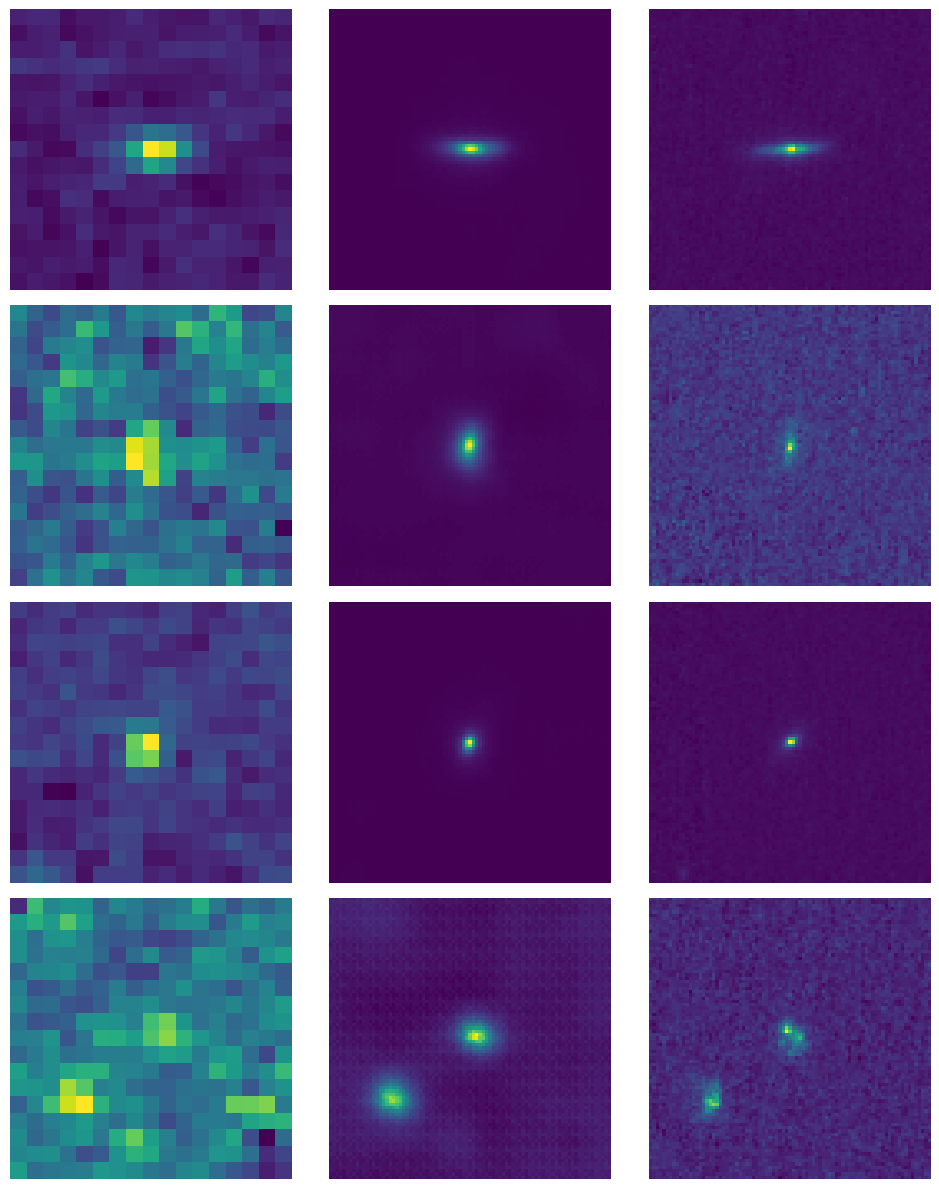

In [24]:
test_loader = DataLoader(
    test_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# === Pick a random test batch ===
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# === Inference ===
with torch.no_grad(), torch.cuda.amp.autocast():
    sr_batch = model(lr_batch).cpu()

# === Convert to numpy for visualization ===
lr_batch_np = lr_batch.cpu().numpy()
sr_batch_np = sr_batch.numpy()
hr_batch_np = hr_batch.cpu().numpy()

# === Plot results ===
num_images = max(4, lr_batch_np.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Res
    img1 = axes[i, 0].imshow(lr_batch_np[i, 0][4:-4,4:-4], cmap='viridis')
    axes[i, 0].axis("off")

    # Super-Resolved
    img2 = axes[i, 1].imshow(sr_batch_np[i, 0][20:-20,20:-20], cmap='viridis')
    axes[i, 1].axis("off")

    # Ground Truth
    img3 = axes[i, 2].imshow(hr_batch_np[i, 0][20:-20,20:-20], cmap='viridis')
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig('claude_result.png')
